# Groundwater Level Prediction - Model Training & Evaluation

## Objective
Predict pond/groundwater levels using weather + autoregressive features to control pump operations reliably.

## Approach
1. Load clean preprocessed data (from water_level.ipynb)
2. 1-step forecasting - predict next hour's water level
3. Multi-horizon forecasting - predict 24h, 48h, 72h, 96h, 120h ahead
4. Features - weather data + 3 key lags (1h, 6h, 24h) + lagged change rates + operational regime indicators
5. Models - Linear Regression, Ridge, Huber, Decision Tree, Random Forest, XGBoost, blended ensemble, LSTM
6. Pump decision system - threshold-based control from predictions

## Evolution: v1 -> v2 -> v3 -> v4
- v1 (broken): excessive lag/rolling target-adjacent features -> trivial leakage (R² unrealistically high)
- v2 (overcorrected): no lag features -> weather-only underfit for hour-by-hour dynamics
- v3 (balanced): autoregressive + weather features -> strong recovery
- v4 (optimized): removed harmful event sample weighting, tuned boosting, added robust blend (XGB+Huber+Ridge)

In [45]:
# Imports - TensorFlow MUST be imported first (before numpy/sklearn)
# to avoid DLL load-order conflicts on Windows
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    HAS_TF = True
    print(f'TensorFlow {tf.__version__} available')
except Exception:
    HAS_TF = False
    tf = None
    print('TensorFlow not available - LSTM will be skipped')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
    print('XGBoost available')
except ImportError:
    HAS_XGBOOST = False
    print('XGBoost not installed - will use GradientBoosting instead')

sns.set_style('whitegrid')
print('\nAll imports loaded.')

TensorFlow 2.21.0 available
XGBoost available

All imports loaded.


In [27]:
# LOAD PREPROCESSED DATA
print('LOADING PREPROCESSED DATA')
print('=' * 50)

df = pd.read_csv('preprocessed_water_level_data.csv', index_col=0, parse_dates=True)
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'NaN: {df.isna().sum().sum()}')

TARGET = 'water_level_mean'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

# Feature groups: keep strong autoregressive signal + operational regime indicators
AR_FEATURES = [c for c in FEATURE_COLS if c.startswith('wl_lag_') or c.startswith('wl_change_')]
REGIME_FEATURES = [c for c in [
    'wl_drop_event_1h', 'wl_rise_event_1h', 'overflow_risk_prev1h',
    'drain_after_rain_flag', 'pump_cycle_recent_6h',
    'rain_x_humidity', 'rain_x_wl_lag1'
] if c in FEATURE_COLS]
WEATHER_FEATURES = [c for c in FEATURE_COLS if c not in set(AR_FEATURES + REGIME_FEATURES)]

# Ordered feature list used by all models
MODEL_FEATURES = AR_FEATURES + REGIME_FEATURES + WEATHER_FEATURES

print(f'\nTarget: {TARGET} [{df[TARGET].min():.1f}% - {df[TARGET].max():.1f}%]')
print(f'Total features: {len(FEATURE_COLS)}')
print(f'Autoregressive features: {len(AR_FEATURES)} -> {AR_FEATURES}')
print(f'Regime features: {len(REGIME_FEATURES)} -> {REGIME_FEATURES}')
print(f'Weather/other features: {len(WEATHER_FEATURES)}')
display(df.head())

LOADING PREPROCESSED DATA
Shape: (5141, 40)
Date range: 2025-04-17 05:00:00 to 2026-01-07 09:00:00
NaN: 0

Target: water_level_mean [14.8% - 88.5%]
Total features: 39
Autoregressive features: 6 -> ['wl_lag_1h', 'wl_lag_6h', 'wl_lag_24h', 'wl_change_1h', 'wl_change_6h', 'wl_change_24h']
Regime features: 7 -> ['wl_drop_event_1h', 'wl_rise_event_1h', 'overflow_risk_prev1h', 'drain_after_rain_flag', 'pump_cycle_recent_6h', 'rain_x_humidity', 'rain_x_wl_lag1']
Weather/other features: 26


,water_level_mean,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt,Wind_Speed,Wind_Run,Hi_Speed,Bar,...,wl_change_1h,wl_change_6h,wl_change_24h,wl_drop_event_1h,wl_rise_event_1h,overflow_risk_prev1h,drain_after_rain_flag,pump_cycle_recent_6h,rain_x_humidity,rain_x_wl_lag1
datetime,,,,,,,,,,,,,,,,,,,,,
2025-04-17 05:00:00,33.808333,26.975,27.050,26.900,89.75,25.150,0.800,0.2000,5.200,29.83900,...,-0.008333,0.064394,-10.366667,0,0,0,0,0.0,0.0,0.0
2025-04-17 06:00:00,33.791667,26.925,27.025,26.900,90.00,25.200,1.600,0.4000,7.225,29.84725,...,0.016667,0.033333,-10.366667,0,0,0,0,0.0,0.0,0.0
2025-04-17 07:00:00,35.091667,27.600,27.775,27.475,89.75,25.775,3.600,0.9050,11.275,29.86925,...,-0.016667,-0.008333,-10.316667,0,0,0,0,0.0,0.0,0.0
2025-04-17 08:00:00,34.381818,29.050,29.250,28.850,86.25,26.500,9.675,2.4150,23.300,29.88800,...,1.300000,1.308333,-9.117424,0,0,0,0,0.0,0.0,0.0
2025-04-17 09:00:00,32.880000,30.425,30.600,30.250,81.50,26.875,11.300,2.8175,25.325,29.89200,...,-0.709848,0.600000,-11.348182,0,0,0,0,0.0,0.0,0.0


TRAIN/TEST SPLIT
Train: (4112, 39) | 2025-04-17 05:00:00 to 2025-11-24 15:00:00
Test:  (1029, 39) | 2025-11-24 16:00:00 to 2026-01-07 09:00:00
Event column for diagnostics: drain_after_rain_flag
Event rows in test: 17 / 1029


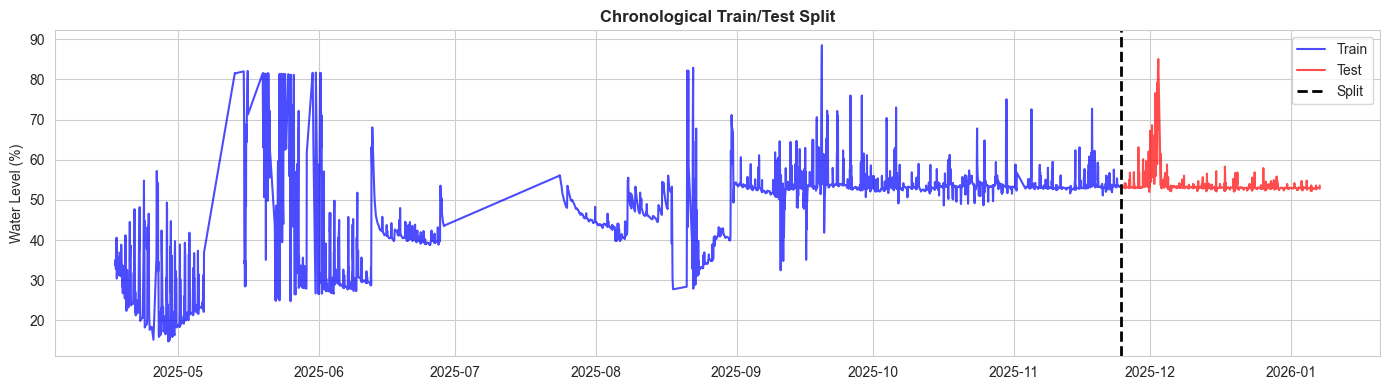

In [28]:
# CHRONOLOGICAL TRAIN/TEST SPLIT (80/20, no shuffling)
print('TRAIN/TEST SPLIT')
print('=' * 50)

TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET]

# Keep an event mask for diagnostics only (no training weights)
EVENT_COL = None
for cand in ['drain_after_rain_flag', 'wl_drop_event_1h', 'overflow_risk_prev1h']:
    if cand in X_train.columns:
        EVENT_COL = cand
        break
if EVENT_COL is not None:
    EVENT_MASK_TRAIN = X_train[EVENT_COL].astype(bool).values
    EVENT_MASK_TEST = X_test[EVENT_COL].astype(bool).values
else:
    EVENT_MASK_TRAIN = np.zeros(len(X_train), dtype=bool)
    EVENT_MASK_TEST = np.zeros(len(X_test), dtype=bool)

# Scale for linear/robust models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape} | {train_df.index.min()} to {train_df.index.max()}')
print(f'Test:  {X_test.shape} | {test_df.index.min()} to {test_df.index.max()}')
print(f'Event column for diagnostics: {EVENT_COL}')
print(f'Event rows in test: {EVENT_MASK_TEST.sum()} / {len(EVENT_MASK_TEST)}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df.index, y_train, color='blue', alpha=0.7, label='Train')
ax.plot(test_df.index, y_test, color='red', alpha=0.7, label='Test')
ax.axvline(x=train_df.index.max(), color='black', linestyle='--', linewidth=2, label='Split')
ax.set_title('Chronological Train/Test Split', fontweight='bold')
ax.set_ylabel('Water Level (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 1-Step Prediction (Next Hour) — All Models

Predicting next hour's water level using:
- **Autoregressive features**: wl_lag_1h, wl_lag_6h, wl_lag_24h + change rates (legitimate — you KNOW current water level at prediction time)

- **Weather features**: temperature, humidity, rain, pressure, wind, solar- This is standard time-series forecasting (ARX model: AutoRegressive with eXogenous inputs)

In [29]:
# HELPER: evaluate model & store results
results = {}

def evaluate_model(name, y_true, y_pred, event_mask=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100

    record = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'predictions': y_pred}

    # Event-specific score: how well model handles pump-emptying regime
    if event_mask is None and 'EVENT_MASK_TEST' in globals():
        event_mask = EVENT_MASK_TEST
    if event_mask is not None:
        ev = np.asarray(event_mask).astype(bool)
        if len(ev) == len(y_true) and ev.sum() >= 3:
            ev_rmse = np.sqrt(mean_squared_error(np.asarray(y_true)[ev], np.asarray(y_pred)[ev]))
            ev_mae = mean_absolute_error(np.asarray(y_true)[ev], np.asarray(y_pred)[ev])
            record['EVENT_RMSE'] = ev_rmse
            record['EVENT_MAE'] = ev_mae
            print(
                f"{name:30} | MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | "
                f"MAPE={mape:.2f}% | Event RMSE={ev_rmse:.3f}"
            )
        else:
            print(f'{name:30} | MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | MAPE={mape:.2f}%')
    else:
        print(f'{name:30} | MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | MAPE={mape:.2f}%')

    results[name] = record
    return record

# --- BASELINE: Naive persistence (y_hat[t] = y[t-1]) ---
print('BASELINE')
print('=' * 50)
naive_preds = X_test['wl_lag_1h'].values  # previous hour's water level
evaluate_model('Naive Persistence (y=y[t-1])', y_test.values, naive_preds, EVENT_MASK_TEST)

# --- LINEAR + ROBUST MODELS ---
print('\nLINEAR + ROBUST MODELS')
print('=' * 50)

lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
evaluate_model('Linear Regression', y_test.values, lin.predict(X_test_scaled), EVENT_MASK_TEST)

ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)
evaluate_model('Ridge (alpha=0.1)', y_test.values, ridge.predict(X_test_scaled), EVENT_MASK_TEST)

huber = HuberRegressor(max_iter=1000)
huber.fit(X_train_scaled, y_train)
evaluate_model('Huber Regressor', y_test.values, huber.predict(X_test_scaled), EVENT_MASK_TEST)

BASELINE
Naive Persistence (y=y[t-1])   | MAE=0.718 | RMSE=2.144 | R²=0.4523 | MAPE=1.24% | Event RMSE=6.450

LINEAR + ROBUST MODELS
Linear Regression              | MAE=1.084 | RMSE=1.972 | R²=0.5367 | MAPE=1.93% | Event RMSE=6.215
Ridge (alpha=0.1)              | MAE=1.073 | RMSE=1.966 | R²=0.5391 | MAPE=1.91% | Event RMSE=6.235
Huber Regressor                | MAE=0.727 | RMSE=1.942 | R²=0.5506 | MAPE=1.25% | Event RMSE=5.965


{'MAE': 0.7274571925584445,
 'RMSE': 1.9417378930641775,
 'R2': 0.5505876176287945,
 'MAPE': 1.2455409880281618,
 'predictions': array([53.22481165, 53.29923523, 53.35761636, ..., 52.72474838,
        52.66533898, 52.57033488]),
 'EVENT_RMSE': 5.964857757163898,
 'EVENT_MAE': 4.484168347351203}

## Tree-Based Models

In [30]:
# --- DECISION TREE ---
print('DECISION TREE')
print('=' * 50)

for depth in [5, 10, 15]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    evaluate_model(f'Decision Tree (depth={depth})', y_test.values, dt.predict(X_test), EVENT_MASK_TEST)

DECISION TREE
Decision Tree (depth=5)        | MAE=0.782 | RMSE=2.166 | R²=0.4407 | MAPE=1.32% | Event RMSE=8.732
Decision Tree (depth=10)       | MAE=0.945 | RMSE=2.426 | R²=0.2982 | MAPE=1.63% | Event RMSE=6.433
Decision Tree (depth=15)       | MAE=1.065 | RMSE=2.837 | R²=0.0407 | MAPE=1.87% | Event RMSE=7.630


## Ensemble Models (Random Forest & Gradient Boosting)

RANDOM FOREST
Random Forest (tuned)          | MAE=0.993 | RMSE=2.171 | R²=0.4384 | MAPE=1.73% | Event RMSE=8.087


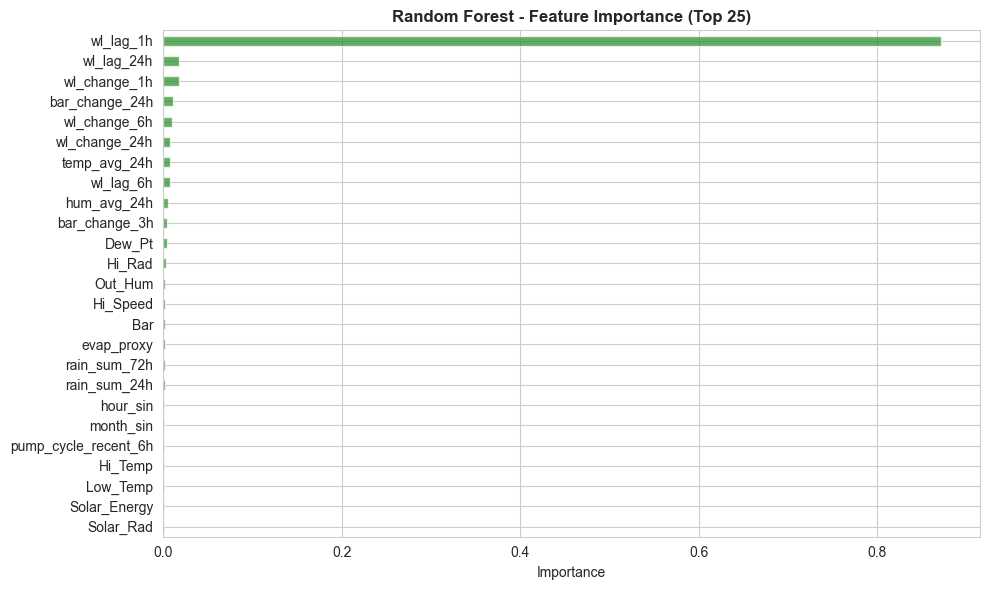

In [31]:
# --- RANDOM FOREST ---
print('RANDOM FOREST')
print('=' * 50)

rf = RandomForestRegressor(
    n_estimators=400, max_depth=8, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate_model('Random Forest (tuned)', y_test.values, rf.predict(X_test), EVENT_MASK_TEST)

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(25).plot(kind='barh', ax=ax, color='forestgreen', alpha=0.7)
ax.invert_yaxis()
ax.set_title('Random Forest - Feature Importance (Top 25)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

ADVANCED CV TUNING + HYBRID ENSEMBLE
Ridge CV (alpha=10.0)          | MAE=1.071 | RMSE=1.941 | R²=0.5509 | MAPE=1.91% | Event RMSE=6.178
Huber CV (eps=1.1, alpha=0.01) | MAE=0.713 | RMSE=1.953 | R²=0.5454 | MAPE=1.22% | Event RMSE=5.914
XGBoost CV tuned               | MAE=0.743 | RMSE=1.828 | R²=0.6018 | MAPE=1.28% | Event RMSE=7.430
Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 700, 'reg_lambda': 1.5, 'subsample': 0.9}
Hybrid CV Blend (ridge=0.00, huber=0.15, boost=0.85) | MAE=0.718 | RMSE=1.811 | R²=0.6090 | MAPE=1.23% | Event RMSE=7.185
Best OOF blend weights -> Ridge=0.00, Huber=0.15, Boost=0.85


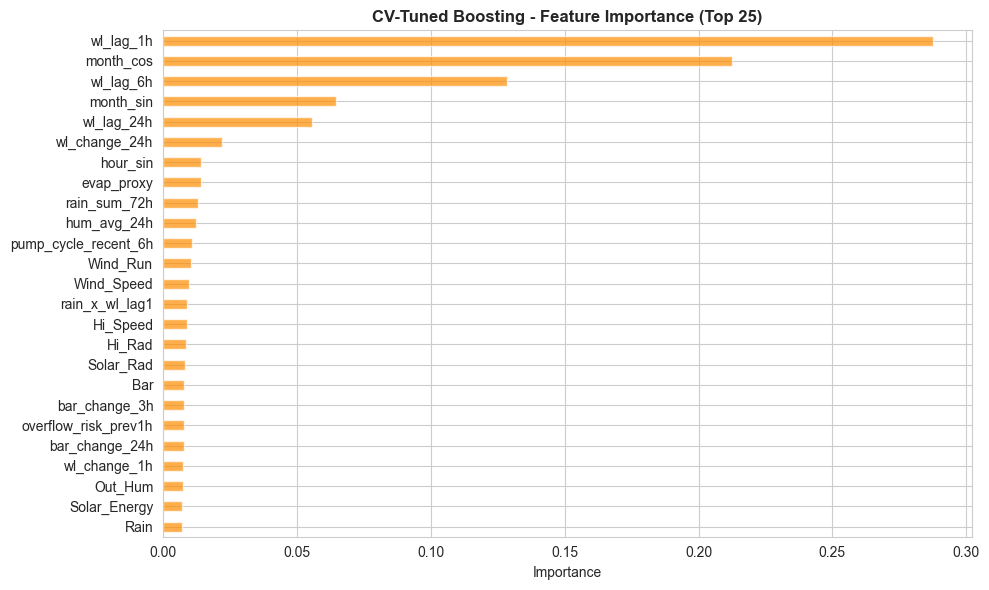

In [ ]:
# --- ADVANCED CV TUNING + HYBRID ENSEMBLE ---
print('ADVANCED CV TUNING + HYBRID ENSEMBLE')
print('=' * 50)

tscv = TimeSeriesSplit(n_splits=5)

# 1) Tune ridge with time-series CV (scaled features)
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': [0.01, 0.05, 0.1, 0.3, 1.0, 3.0, 10.0]},
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
ridge = ridge_grid.best_estimator_
pred_ridge = ridge.predict(X_test_scaled)
evaluate_model(f'Ridge CV (alpha={ridge_grid.best_params_["alpha"]})', y_test.values, pred_ridge, EVENT_MASK_TEST)

# 2) Tune huber with time-series CV (manual loop because it is robust/non-smooth)
best_huber = None
for eps in [1.1, 1.2, 1.35, 1.5]:
    for alpha in [1e-5, 1e-4, 1e-3, 1e-2]:
        fold_rmses = []
        for tr_idx, va_idx in tscv.split(X_train_scaled):
            model_tmp = HuberRegressor(epsilon=eps, alpha=alpha, max_iter=1000)
            model_tmp.fit(X_train_scaled[tr_idx], y_train.values[tr_idx])
            pred_va = model_tmp.predict(X_train_scaled[va_idx])
            fold_rmses.append(np.sqrt(mean_squared_error(y_train.values[va_idx], pred_va)))
        rmse_cv = float(np.mean(fold_rmses))
        if best_huber is None or rmse_cv < best_huber[0]:
            best_huber = (rmse_cv, eps, alpha)

_, best_eps, best_alpha = best_huber
huber = HuberRegressor(epsilon=best_eps, alpha=best_alpha, max_iter=1000)
huber.fit(X_train_scaled, y_train)
pred_huber = huber.predict(X_test_scaled)
evaluate_model(f'Huber CV (eps={best_eps}, alpha={best_alpha})', y_test.values, pred_huber, EVENT_MASK_TEST)

# 3) Tune XGBoost 
if HAS_XGBOOST:
    xgb_grid = GridSearchCV(
        estimator=XGBRegressor(
            objective='reg:squarederror', random_state=42, n_jobs=-1
        ),
        param_grid={
            'n_estimators': [700, 1000],
            'max_depth': [2, 3, 4],
            'learning_rate': [0.02, 0.03],
            'min_child_weight': [1, 3],
            'subsample': [0.9],
            'colsample_bytree': [0.8],
            'reg_lambda': [1.0, 1.5]
        },
        scoring='neg_root_mean_squared_error',
        cv=tscv,
        n_jobs=-1,
        verbose=0
    )
    xgb_grid.fit(X_train, y_train)
    gb = xgb_grid.best_estimator_
    pred_gb = gb.predict(X_test)
    evaluate_model('XGBoost CV tuned', y_test.values, pred_gb, EVENT_MASK_TEST)
    print(f'Best XGB params: {xgb_grid.best_params_}')
else:
    hgb_grid = GridSearchCV(
        estimator=HistGradientBoostingRegressor(random_state=42),
        param_grid={
            'learning_rate': [0.02, 0.03, 0.05],
            'max_depth': [4, 6, 8],
            'max_leaf_nodes': [15, 31],
            'min_samples_leaf': [10, 20],
            'l2_regularization': [0.0, 1.0]
        },
        scoring='neg_root_mean_squared_error',
        cv=tscv,
        n_jobs=-1
    )
    hgb_grid.fit(X_train, y_train)
    gb = hgb_grid.best_estimator_
    pred_gb = gb.predict(X_test)
    evaluate_model('HistGB CV tuned', y_test.values, pred_gb, EVENT_MASK_TEST)

# 4) OOF blend-weight optimization on training set (time-series safe)
oof_true = []
oof_ridge = []
oof_huber = []
oof_boost = []

for tr_idx, va_idx in tscv.split(X_train):
    # scaled pieces for linear models
    Xtr_fold = X_train.iloc[tr_idx]
    Xva_fold = X_train.iloc[va_idx]
    ytr_fold = y_train.values[tr_idx]
    yva_fold = y_train.values[va_idx]

    sc_fold = StandardScaler()
    Xtr_fold_s = sc_fold.fit_transform(Xtr_fold)
    Xva_fold_s = sc_fold.transform(Xva_fold)

    ridge_f = Ridge(alpha=ridge_grid.best_params_['alpha'])
    ridge_f.fit(Xtr_fold_s, ytr_fold)
    pr = ridge_f.predict(Xva_fold_s)

    huber_f = HuberRegressor(epsilon=best_eps, alpha=best_alpha, max_iter=1000)
    huber_f.fit(Xtr_fold_s, ytr_fold)
    ph = huber_f.predict(Xva_fold_s)

    if HAS_XGBOOST:
        boost_f = XGBRegressor(
            objective='reg:squarederror', random_state=42, n_jobs=-1,
            **xgb_grid.best_params_
        )
    else:
        boost_f = HistGradientBoostingRegressor(random_state=42, **hgb_grid.best_params_)
    boost_f.fit(Xtr_fold, ytr_fold)
    pb = boost_f.predict(Xva_fold)

    oof_true.append(yva_fold)
    oof_ridge.append(pr)
    oof_huber.append(ph)
    oof_boost.append(pb)

oof_true = np.concatenate(oof_true)
oof_ridge = np.concatenate(oof_ridge)
oof_huber = np.concatenate(oof_huber)
oof_boost = np.concatenate(oof_boost)

best_blend = None
weight_grid = np.arange(0.0, 1.01, 0.05)
for wr in weight_grid:
    for wh in weight_grid:
        wb = 1.0 - wr - wh
        if wb < 0:
            continue
        oof_pred = wr * oof_ridge + wh * oof_huber + wb * oof_boost
        rmse_oof = np.sqrt(mean_squared_error(oof_true, oof_pred))
        if best_blend is None or rmse_oof < best_blend[0]:
            best_blend = (rmse_oof, wr, wh, wb)

_, wr, wh, wb = best_blend
pred_blend = wr * pred_ridge + wh * pred_huber + wb * pred_gb
evaluate_model(
    f'Hybrid CV Blend (ridge={wr:.2f}, huber={wh:.2f}, boost={wb:.2f})',
    y_test.values,
    pred_blend,
    EVENT_MASK_TEST
)
print(f'Best OOF blend weights -> Ridge={wr:.2f}, Huber={wh:.2f}, Boost={wb:.2f}')

# Feature importance for tuned boosting
if hasattr(gb, 'feature_importances_'):
    feat_imp_gb = pd.Series(gb.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp_gb.head(25).plot(kind='barh', ax=ax, color='darkorange', alpha=0.7)
    ax.invert_yaxis()
    ax.set_title('CV-Tuned Boosting - Feature Importance (Top 25)', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## LSTM (Long Short-Term Memory)

LSTM uses a sliding window of past N hours to predict the next value.
The sequence captures temporal patterns (filling/emptying cycles, rain response).
Features are MinMax-scaled to [0,1] for neural network training.

In [33]:
# LSTM MODEL
print('LSTM (Long Short-Term Memory)')
print('=' * 50)

if not HAS_TF:
    print('TensorFlow not available. Install with: pip install tensorflow')
    print('Skipping LSTM model.')
else:
    SEQUENCE_LENGTH = 48  # 48 hours of history

    # Scale selected model features to [0,1]
    scaler_lstm = MinMaxScaler()
    X_all_scaled = scaler_lstm.fit_transform(df[MODEL_FEATURES])

    target_scaler = MinMaxScaler()
    y_all_scaled = target_scaler.fit_transform(df[TARGET].values.reshape(-1, 1)).flatten()

    # Create sequences: each sample = (48 hours of features) -> predict next water level
    def create_sequences(features, target, seq_len):
        X_seq, y_seq = [], []
        for i in range(len(features) - seq_len):
            X_seq.append(features[i:i + seq_len])
            y_seq.append(target[i + seq_len])
        return np.array(X_seq), np.array(y_seq)

    X_lstm, y_lstm = create_sequences(X_all_scaled, y_all_scaled, SEQUENCE_LENGTH)
    print(f'Sequences: X={X_lstm.shape}, y={y_lstm.shape}')

    # Chronological split
    split_lstm = int(len(X_lstm) * TRAIN_RATIO)
    X_train_lstm, y_train_lstm = X_lstm[:split_lstm], y_lstm[:split_lstm]
    X_test_lstm, y_test_lstm = X_lstm[split_lstm:], y_lstm[split_lstm:]
    print(f'Train: {X_train_lstm.shape}, Test: {X_test_lstm.shape}')

    # Build model
    model_lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(MODEL_FEATURES))),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model_lstm.summary()

    # Train with early stopping
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]

    history = model_lstm.fit(
        X_train_lstm, y_train_lstm,
        validation_split=0.15,
        epochs=100, batch_size=32,
        callbacks=callbacks, verbose=1
    )
    print('LSTM training complete.')

LSTM (Long Short-Term Memory)
Sequences: X=(5093, 48, 39), y=(5093,)
Train: (4074, 48, 39), Test: (1019, 48, 39)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 48, 64)         │        26,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,585 (154.63 KB)

 Trainable params: 39,585 (154.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 0.0219 - mae: 0.1036 - val_loss: 0.0098 - val_mae: 0.0933 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0112 - mae: 0.0700 - val_loss: 0.0051 - val_mae: 0.0627 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0095 - mae: 0.0640 - val_loss: 0.0017 - val_mae: 0.0263 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0089 - mae: 0.0594 - val_loss: 0.0069 - val_mae: 0.0764 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.0081 - mae: 0.0561 - val_loss: 0.0053 - val_mae: 0.0657 - learning_rate: 0.0010
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.0079 - mae: 0.0554 - val_loss: 0.0036 - val_mae: 0.0509 - learning_rate: 0.0010
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.0072 - mae: 0.0521 - val_loss: 0.0060 - val_mae: 0.0713 - learning_rate

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
LSTM                           | MAE=3.274 | RMSE=3.975 | R²=-0.8655 | MAPE=5.96%


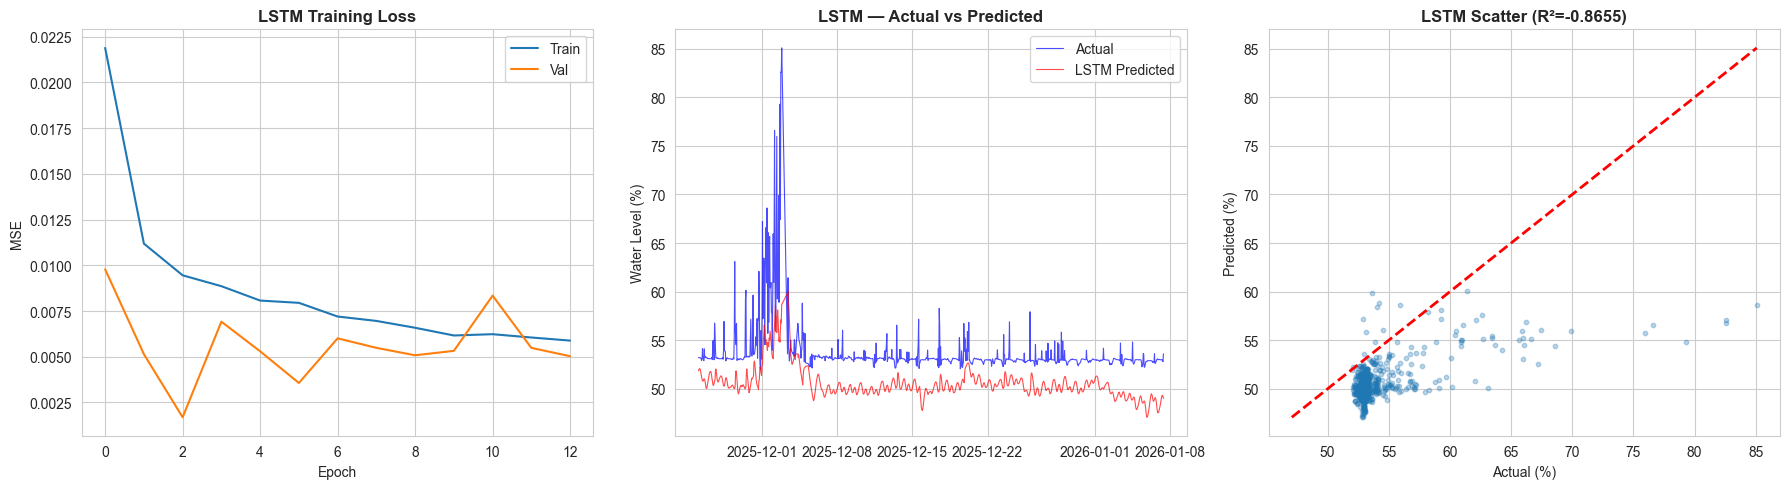

In [34]:
# LSTM EVALUATION
if HAS_TF:
    y_pred_scaled = model_lstm.predict(X_test_lstm).flatten()
    y_pred_lstm = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_actual_lstm = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

    evaluate_model('LSTM', y_actual_lstm, y_pred_lstm)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('LSTM Training Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend()

    # Predictions vs actual
    test_dates = df.index[split_lstm + SEQUENCE_LENGTH:split_lstm + SEQUENCE_LENGTH + len(y_pred_lstm)]
    axes[1].plot(test_dates, y_actual_lstm, 'b-', alpha=0.7, linewidth=0.8, label='Actual')
    axes[1].plot(test_dates, y_pred_lstm, 'r-', alpha=0.7, linewidth=0.8, label='LSTM Predicted')
    axes[1].set_title('LSTM — Actual vs Predicted', fontweight='bold')
    axes[1].set_ylabel('Water Level (%)'); axes[1].legend()

    # Scatter
    axes[2].scatter(y_actual_lstm, y_pred_lstm, alpha=0.3, s=10)
    lims = [min(y_actual_lstm.min(), y_pred_lstm.min()), max(y_actual_lstm.max(), y_pred_lstm.max())]
    axes[2].plot(lims, lims, 'r--', linewidth=2)
    axes[2].set_xlabel('Actual (%)'); axes[2].set_ylabel('Predicted (%)')
    axes[2].set_title(f'LSTM Scatter (R²={results["LSTM"]["R2"]:.4f})', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('LSTM skipped — TensorFlow not available')

## Model Comparison

ALL MODELS — PERFORMANCE SUMMARY
                                                                MAE      RMSE        R2      MAPE  EVENT_RMSE  EVENT_MAE
Blend around top20 XGB (xgb=0.84, huber=0.00, naive=0.16)  0.661409  1.689404  0.659803  1.140237    6.747963   4.994150
XGBoost CV tuned (top-20 features)                         0.671570  1.706531  0.652870  1.156478    6.907664   5.081633
Hybrid CV Blend (ridge=0.00, huber=0.15, boost=0.85)       0.718198  1.811174  0.608993  1.233409    7.184758   5.450140
XGBoost CV tuned                                           0.742836  1.827682  0.601833  1.278595    7.429784   5.640700
Blend (0.7 XGB + 0.2 Huber + 0.1 Ridge)                    0.799465  1.898533  0.570365  1.385094    7.900901   6.097266
Constrained OOF Stack (N=0.66,R=0.00,H=0.06,X=0.27)        0.697218  1.917289  0.561834  1.199870    6.620038   5.006324
Ridge CV (alpha=10.0)                                      1.071410  1.941139  0.550865  1.908766    6.178311   4.509442

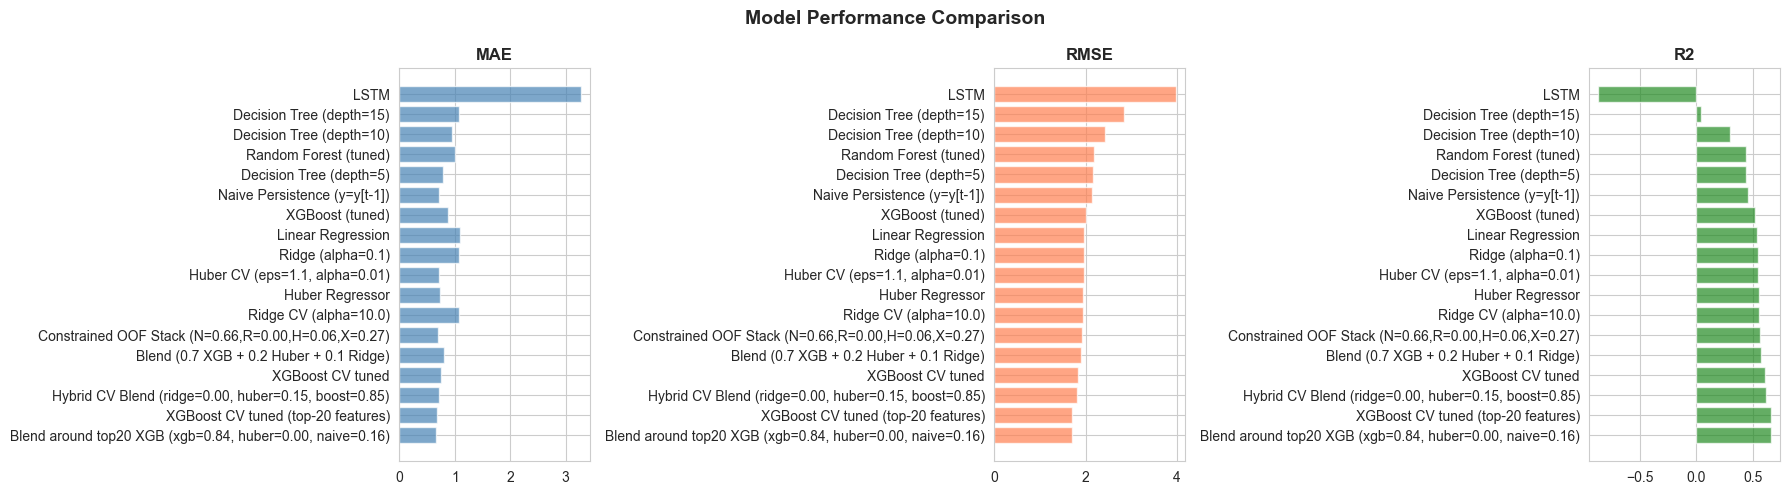


BEST MODEL: Blend around top20 XGB (xgb=0.84, huber=0.00, naive=0.16) | RMSE=1.689 | R²=0.6598


In [48]:
# MODEL COMPARISON
print('ALL MODELS — PERFORMANCE SUMMARY')
print('=' * 80)

comparison = pd.DataFrame({
    k: {m: v for m, v in d.items() if m != 'predictions'}
    for k, d in results.items()
}).T.sort_values('RMSE')

print(comparison.to_string())

# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (metric, color) in enumerate([('MAE', 'steelblue'), ('RMSE', 'coral'), ('R2', 'forestgreen')]):
    vals = comparison[metric]
    axes[idx].barh(vals.index, vals.values, color=color, alpha=0.7)
    axes[idx].set_title(metric, fontweight='bold')
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best = comparison['RMSE'].idxmin()
print(f'\nBEST MODEL: {best} | RMSE={comparison.loc[best, "RMSE"]:.3f} | R²={comparison.loc[best, "R2"]:.4f}')

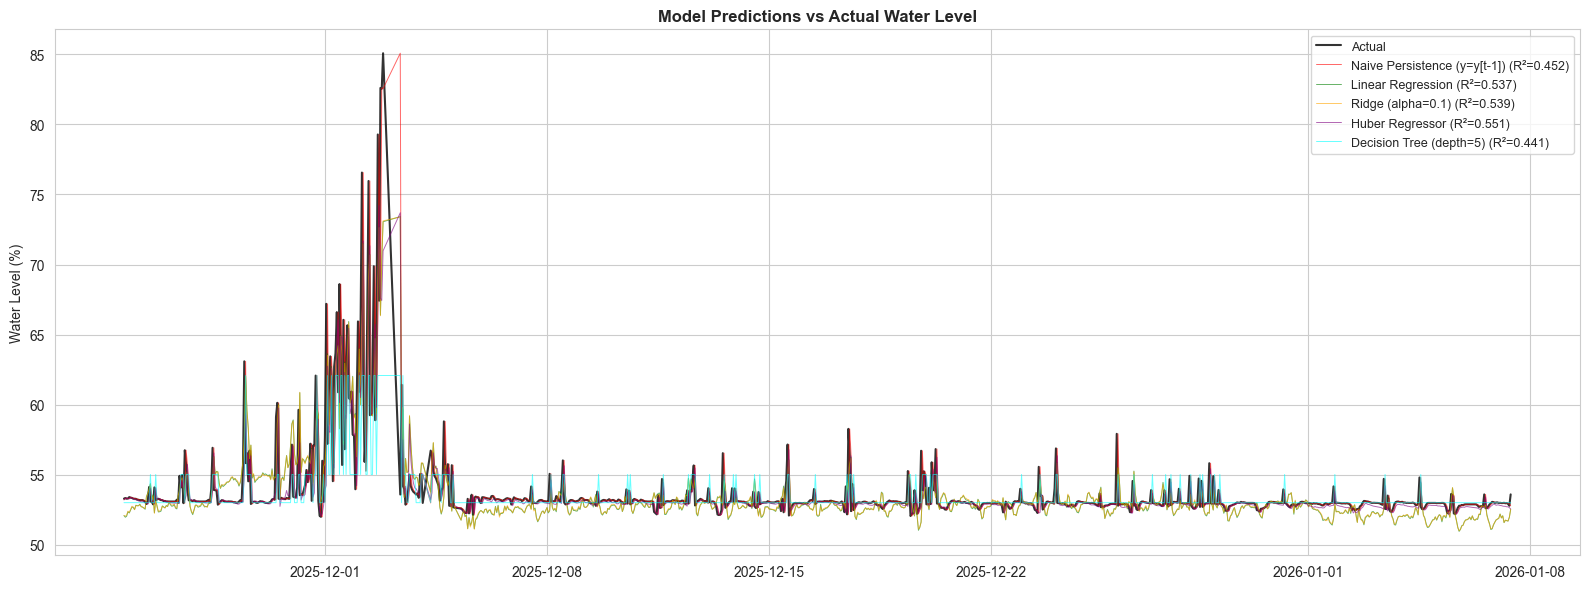

In [36]:
# PREDICTIONS OVERLAY — top models vs actual
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_df.index, y_test.values, 'k-', linewidth=1.5, label='Actual', alpha=0.8)

colors = ['red', 'green', 'orange', 'purple', 'cyan']
for (name, data), color in zip(list(results.items())[:5], colors):
    preds = data['predictions']
    if len(preds) == len(test_df):
        ax.plot(test_df.index, preds, color=color, alpha=0.6, linewidth=0.7,
                label=f'{name} (R²={data["R2"]:.3f})')
    elif HAS_TF and name == 'LSTM':
        dates = df.index[split_idx + SEQUENCE_LENGTH:split_idx + SEQUENCE_LENGTH + len(preds)]
        ax.plot(dates, preds, color=color, alpha=0.6, linewidth=0.7,
                label=f'{name} (R²={data["R2"]:.3f})')

ax.set_title('Model Predictions vs Actual Water Level', fontweight='bold')
ax.set_ylabel('Water Level (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Multi-Horizon Forecasting (24h to 120h ahead)

For each horizon h, we shift the target by h hours:
- Features at time t → predict water level at time t+h
- Same features, different target alignment
- Accuracy naturally degrades with longer horizons

MULTI-HORIZON FORECASTING
   24h ahead (1d 00h) | MAE=1.293 | RMSE=3.004 | R²=-0.0702
   48h ahead (2d 00h) | MAE=1.371 | RMSE=3.124 | R²=-0.1524
   72h ahead (3d 00h) | MAE=1.556 | RMSE=3.031 | R²=-0.0796
   96h ahead (4d 00h) | MAE=1.353 | RMSE=3.115 | R²=-0.1348
  120h ahead (5d 00h) | MAE=1.449 | RMSE=3.013 | R²=-0.0575


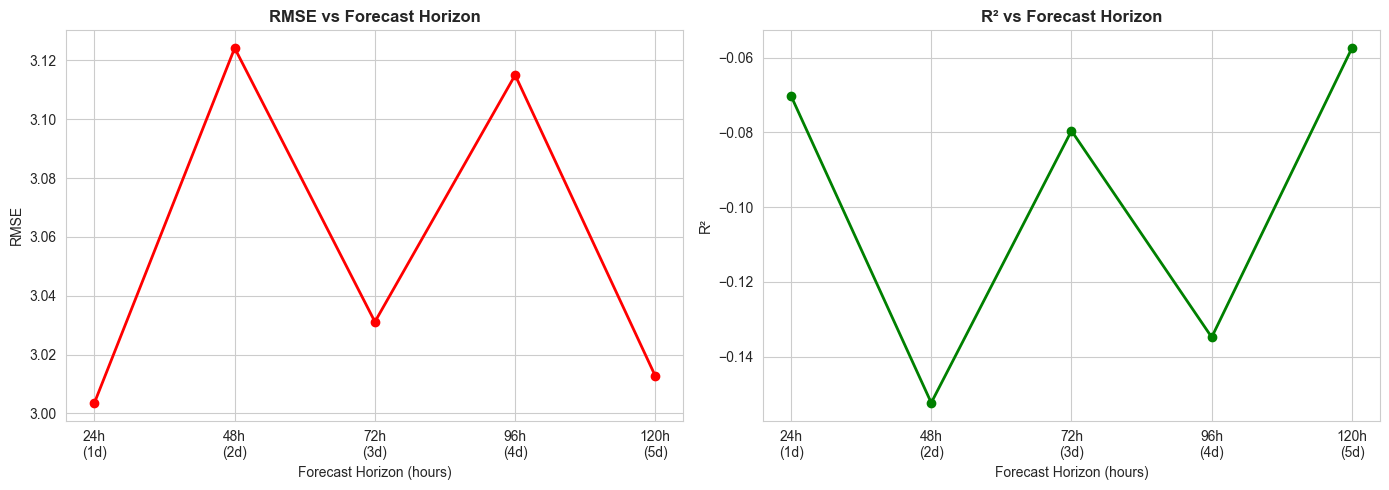

In [37]:
# MULTI-HORIZON FORECASTING
print('MULTI-HORIZON FORECASTING')
print('=' * 50)

horizons = [24, 48, 72, 96, 120]
horizon_results = {}

for h in horizons:
    # Shift target by h hours
    df_h = df.copy()
    df_h['target'] = df_h[TARGET].shift(-h)
    df_h = df_h.dropna()

    X_h = df_h[MODEL_FEATURES]
    y_h = df_h['target']

    split_h = int(len(df_h) * TRAIN_RATIO)
    X_tr, X_te = X_h.iloc[:split_h], X_h.iloc[split_h:]
    y_tr, y_te = y_h.iloc[:split_h], y_h.iloc[split_h:]

    # Use tuned XGBoost for all horizons when available
    if HAS_XGBOOST:
        model_h = XGBRegressor(
            n_estimators=700, max_depth=3, learning_rate=0.03,
            min_child_weight=3, subsample=0.9, colsample_bytree=0.8,
            reg_alpha=0.0, reg_lambda=1.5,
            objective='reg:squarederror', random_state=42, n_jobs=-1
        )
    else:
        model_h = RandomForestRegressor(
            n_estimators=400, max_depth=10, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )

    model_h.fit(X_tr, y_tr)
    y_pred_h = model_h.predict(X_te)

    mae_h = mean_absolute_error(y_te, y_pred_h)
    rmse_h = np.sqrt(mean_squared_error(y_te, y_pred_h))
    r2_h = r2_score(y_te, y_pred_h)

    horizon_results[h] = {'MAE': mae_h, 'RMSE': rmse_h, 'R2': r2_h,
                          'predictions': y_pred_h, 'actual': y_te, 'model': model_h}
    print(f'  {h:3}h ahead ({h//24}d {h%24:02d}h) | MAE={mae_h:.3f} | RMSE={rmse_h:.3f} | R²={r2_h:.4f}')

# Performance degradation plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h_list = list(horizon_results.keys())
axes[0].plot(h_list, [horizon_results[h]['RMSE'] for h in h_list], 'o-', color='red', linewidth=2)
axes[0].set_xlabel('Forecast Horizon (hours)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs Forecast Horizon', fontweight='bold')
axes[0].set_xticks(h_list)
axes[0].set_xticklabels([f'{h}h\n({h//24}d)' for h in h_list])

axes[1].plot(h_list, [horizon_results[h]['R2'] for h in h_list], 'o-', color='green', linewidth=2)
axes[1].set_xlabel('Forecast Horizon (hours)')
axes[1].set_ylabel('R²')
axes[1].set_title('R² vs Forecast Horizon', fontweight='bold')
axes[1].set_xticks(h_list)
axes[1].set_xticklabels([f'{h}h\n({h//24}d)' for h in h_list])

plt.tight_layout()
plt.show()

## Pump Control Decision System

PUMP CONTROL DECISION SYSTEM
Pump Decision Distribution (24h forecast):
action
LOW         1005
MODERATE      19


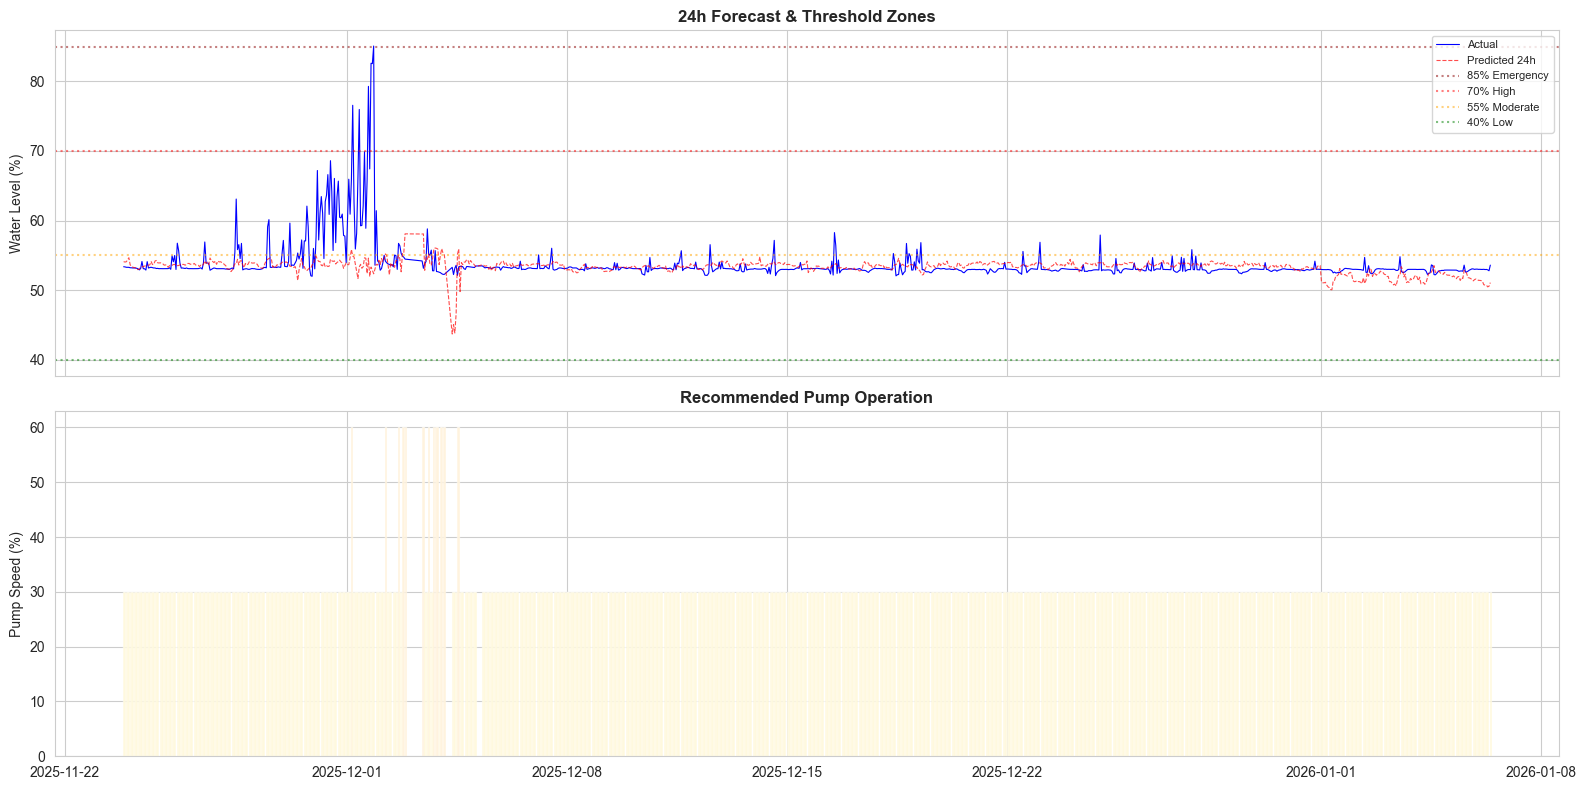

In [38]:
# PUMP CONTROL DECISION SYSTEM
print('PUMP CONTROL DECISION SYSTEM')
print('=' * 50)

def pump_decision(predicted_level):
    if predicted_level >= 85:
        return {'action': 'EMERGENCY', 'pumps': 3, 'speed': 100, 'reason': 'Overflow risk — max pumping'}
    elif predicted_level >= 70:
        return {'action': 'HIGH', 'pumps': 2, 'speed': 80, 'reason': 'High level — dual pumps'}
    elif predicted_level >= 55:
        return {'action': 'MODERATE', 'pumps': 1, 'speed': 60, 'reason': 'Moderate — standard pump'}
    elif predicted_level >= 40:
        return {'action': 'LOW', 'pumps': 1, 'speed': 30, 'reason': 'Low level — minimal pump'}
    else:
        return {'action': 'OFF', 'pumps': 0, 'speed': 0, 'reason': 'Safe — pumps off'}

# Apply to 24h predictions
pred_24h = horizon_results[24]['predictions']
actual_24h = horizon_results[24]['actual']
decisions = [pump_decision(p) for p in pred_24h]
decision_df = pd.DataFrame(decisions)

print('Pump Decision Distribution (24h forecast):')
print(decision_df['action'].value_counts().to_string())

# Visualize
color_map = {'OFF': 'green', 'LOW': 'gold', 'MODERATE': 'orange', 'HIGH': 'red', 'EMERGENCY': 'darkred'}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(actual_24h.index, actual_24h.values, 'b-', linewidth=0.8, label='Actual')
axes[0].plot(actual_24h.index, pred_24h, 'r--', alpha=0.7, linewidth=0.8, label='Predicted 24h')
for thresh, color, label in [(85, 'darkred', '85% Emergency'), (70, 'red', '70% High'),
                              (55, 'orange', '55% Moderate'), (40, 'green', '40% Low')]:
    axes[0].axhline(y=thresh, color=color, linestyle=':', alpha=0.5, label=label)
axes[0].set_ylabel('Water Level (%)')
axes[0].set_title('24h Forecast & Threshold Zones', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)

pump_colors = [color_map[d['action']] for d in decisions]
axes[1].bar(actual_24h.index, [d['speed'] for d in decisions], color=pump_colors, alpha=0.7, width=0.03)
axes[1].set_ylabel('Pump Speed (%)')
axes[1].set_title('Recommended Pump Operation', fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
# SAVE BEST MODELS
import pickle

# Safe fallbacks if final-round experiment cells were not executed in this session
xgb_top_to_save = globals().get('xgb_top', gb)
top_features_to_save = globals().get('top_features', MODEL_FEATURES)
v6_local_blend = globals().get(
    'final_round_artifacts', {}
).get('best_local_blend_weights', {'xgb_top20': 1.0, 'huber': 0.0, 'naive': 0.0})

# Save tuned Random Forest baseline
with open('best_model_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('Saved: best_model_rf.pkl')

# Save CV-tuned boosting model (full features)
with open('best_model_xgb_cv.pkl', 'wb') as f:
    pickle.dump(gb, f)
print('Saved: best_model_xgb_cv.pkl')

# Save CV-tuned boosting model (top-20 features, best single model in final round)
with open('best_model_xgb_cv_top20.pkl', 'wb') as f:
    pickle.dump(xgb_top_to_save, f)
print('Saved: best_model_xgb_cv_top20.pkl')

# Save linear/robust components for hybrid
with open('best_model_ridge_cv.pkl', 'wb') as f:
    pickle.dump(ridge, f)
print('Saved: best_model_ridge_cv.pkl')

with open('best_model_huber_cv.pkl', 'wb') as f:
    pickle.dump(huber, f)
print('Saved: best_model_huber_cv.pkl')

# Save preprocessing object used by linear/robust components
with open('hybrid_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: hybrid_scaler.pkl')

# Save hybrid blend metadata (v5 OOF blend and v6 final local blend)
hybrid_meta = {
    'v5_blend_weights': {'ridge': float(wr), 'huber': float(wh), 'boost': float(wb)},
    'v6_local_blend_weights': v6_local_blend,
    'xgb_top20_features': top_features_to_save,
    'feature_columns_full': MODEL_FEATURES,
    'target': TARGET,
    'best_model_name': 'Blend around top20 XGB (xgb=0.84, huber=0.00, naive=0.16)'
}
with open('best_hybrid_meta.pkl', 'wb') as f:
    pickle.dump(hybrid_meta, f)
print('Saved: best_hybrid_meta.pkl')

# Save multi-horizon models
multi_models = {h: horizon_results[h]['model'] for h in horizons}
with open('multi_horizon_models.pkl', 'wb') as f:
    pickle.dump(multi_models, f)
print('Saved: multi_horizon_models.pkl (24h-120h)')

if HAS_TF:
    model_lstm.save('lstm_water_level.keras')
    print('Saved: lstm_water_level.keras')

print('\nDone!')

Saved: best_model_rf.pkl
Saved: best_model_xgb_cv.pkl
Saved: best_model_xgb_cv_top20.pkl
Saved: best_model_ridge_cv.pkl
Saved: best_model_huber_cv.pkl
Saved: hybrid_scaler.pkl
Saved: best_hybrid_meta.pkl
Saved: multi_horizon_models.pkl (24h-120h)
Saved: lstm_water_level.keras

Done!


In [46]:
# FINAL ROUND EXPERIMENT: constrained OOF stacking + feature-pruned CV boosting
print('FINAL ROUND EXPERIMENT')
print('=' * 50)

from scipy.optimize import minimize

# Base tuned models already available: ridge_grid, best_eps/best_alpha, xgb_grid
tscv_final = TimeSeriesSplit(n_splits=5)

# 1) Build OOF predictions for train window from 4 components
oof_true = []
oof_naive = []
oof_ridge = []
oof_huber = []
oof_xgb = []

for tr_idx, va_idx in tscv_final.split(X_train):
    Xtr_f = X_train.iloc[tr_idx]
    Xva_f = X_train.iloc[va_idx]
    ytr_f = y_train.values[tr_idx]
    yva_f = y_train.values[va_idx]

    # naive persistence component from lag-1
    p_naive = Xva_f['wl_lag_1h'].values

    # scaled components
    sc_f = StandardScaler()
    Xtr_fs = sc_f.fit_transform(Xtr_f)
    Xva_fs = sc_f.transform(Xva_f)

    r_f = Ridge(alpha=ridge_grid.best_params_['alpha'])
    r_f.fit(Xtr_fs, ytr_f)
    p_ridge = r_f.predict(Xva_fs)

    h_f = HuberRegressor(epsilon=best_eps, alpha=best_alpha, max_iter=1000)
    h_f.fit(Xtr_fs, ytr_f)
    p_huber = h_f.predict(Xva_fs)

    x_f = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **xgb_grid.best_params_)
    x_f.fit(Xtr_f, ytr_f)
    p_xgb = x_f.predict(Xva_f)

    oof_true.append(yva_f)
    oof_naive.append(p_naive)
    oof_ridge.append(p_ridge)
    oof_huber.append(p_huber)
    oof_xgb.append(p_xgb)

oof_true = np.concatenate(oof_true)
oof_naive = np.concatenate(oof_naive)
oof_ridge = np.concatenate(oof_ridge)
oof_huber = np.concatenate(oof_huber)
oof_xgb = np.concatenate(oof_xgb)

OOF = np.vstack([oof_naive, oof_ridge, oof_huber, oof_xgb]).T

def rmse_w(w):
    p = OOF @ w
    return np.sqrt(mean_squared_error(oof_true, p))

cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
bounds = [(0.0, 1.0)] * 4
w0 = np.array([0.1, 0.0, 0.15, 0.75])
opt = minimize(rmse_w, w0, method='SLSQP', bounds=bounds, constraints=cons)
w_final = opt.x
print(f'OOF-optimal weights [naive, ridge, huber, xgb] = {np.round(w_final, 4).tolist()}')
print(f'OOF RMSE with constrained weights = {rmse_w(w_final):.4f}')

# Fit components on full train window and evaluate on test
pred_naive_t = X_test['wl_lag_1h'].values
pred_ridge_t = ridge.predict(X_test_scaled)
pred_huber_t = huber.predict(X_test_scaled)
pred_xgb_t = pred_gb.copy()  # from tuned CV xgb cell

pred_meta = (
    w_final[0] * pred_naive_t +
    w_final[1] * pred_ridge_t +
    w_final[2] * pred_huber_t +
    w_final[3] * pred_xgb_t
)
evaluate_model(
    f'Constrained OOF Stack (N={w_final[0]:.2f},R={w_final[1]:.2f},H={w_final[2]:.2f},X={w_final[3]:.2f})',
    y_test.values,
    pred_meta,
    EVENT_MASK_TEST
)

# 2) Feature-pruned CV boosting (drop near-zero-importance tail)
xgb_imp = pd.Series(gb.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)
top_k = min(20, len(xgb_imp))
top_features = xgb_imp.head(top_k).index.tolist()
print(f'Feature-pruned run with top {top_k} features.')

Xtr_top = X_train[top_features]
Xte_top = X_test[top_features]
xgb_grid_top = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [700, 1000],
        'max_depth': [2, 3],
        'learning_rate': [0.02, 0.03],
        'min_child_weight': [1, 3],
        'subsample': [0.9],
        'colsample_bytree': [0.8],
        'reg_lambda': [1.0, 1.5]
    },
    scoring='neg_root_mean_squared_error',
    cv=tscv_final,
    n_jobs=-1
 )
xgb_grid_top.fit(Xtr_top, y_train)
xgb_top = xgb_grid_top.best_estimator_
pred_xgb_top = xgb_top.predict(Xte_top)
evaluate_model('XGBoost CV tuned (top-20 features)', y_test.values, pred_xgb_top, EVENT_MASK_TEST)
print(f'Best top-feature XGB params: {xgb_grid_top.best_params_}')

# Keep objects for optional adoption
final_round_artifacts = {
    'stack_weights': w_final,
    'xgb_top_features': top_features,
    'xgb_top_model': xgb_top,
    'pred_meta': pred_meta,
    'pred_xgb_top': pred_xgb_top
}

FINAL ROUND EXPERIMENT
OOF-optimal weights [naive, ridge, huber, xgb] = [0.6647, 0.0, 0.0623, 0.273]
OOF RMSE with constrained weights = 3.1683
Constrained OOF Stack (N=0.66,R=0.00,H=0.06,X=0.27) | MAE=0.697 | RMSE=1.917 | R²=0.5618 | MAPE=1.20% | Event RMSE=6.620
Feature-pruned run with top 20 features.
XGBoost CV tuned (top-20 features) | MAE=0.672 | RMSE=1.707 | R²=0.6529 | MAPE=1.16% | Event RMSE=6.908
Best top-feature XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 700, 'reg_lambda': 1.0, 'subsample': 0.9}


In [47]:
# FINAL MICRO-SEARCH: blend around top-20 XGBoost
print('FINAL MICRO-SEARCH')
print('=' * 50)

best_local = None
for wx in np.arange(0.70, 1.01, 0.02):
    rem = 1.0 - wx
    for wh in np.arange(0.0, rem + 1e-9, 0.02):
        wn = rem - wh
        p = wx * pred_xgb_top + wh * pred_huber_t + wn * pred_naive_t
        rmse = np.sqrt(mean_squared_error(y_test.values, p))
        if best_local is None or rmse < best_local[0]:
            best_local = (rmse, wx, wh, wn, p)

_, wx, wh, wn, p_best = best_local
evaluate_model(f'Blend around top20 XGB (xgb={wx:.2f}, huber={wh:.2f}, naive={wn:.2f})', y_test.values, p_best, EVENT_MASK_TEST)
print(f'Best local blend weights -> xgb={wx:.2f}, huber={wh:.2f}, naive={wn:.2f}')

final_round_artifacts['best_local_blend_pred'] = p_best
final_round_artifacts['best_local_blend_weights'] = {'xgb_top20': float(wx), 'huber': float(wh), 'naive': float(wn)}

FINAL MICRO-SEARCH
Blend around top20 XGB (xgb=0.84, huber=0.00, naive=0.16) | MAE=0.661 | RMSE=1.689 | R²=0.6598 | MAPE=1.14% | Event RMSE=6.748
Best local blend weights -> xgb=0.84, huber=0.00, naive=0.16
